In [326]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Visualization

### Data preparation for visualization

In [327]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)



### Equity Curve

In [328]:
def plot_equity_curve(df, ax, ticker):
    if 'Cum_Bench' not in df.columns:
        df['Cum_Bench'] = df['Log_Return'].cumsum()
    if 'Cum_Strat' not in df.columns and 'Strategy_Return' in df.columns:
        df['Cum_Strat'] = df['Strategy_Return'].cumsum()
    
    ax.plot(df['Date'], df['Cum_Bench'], label='Benchmark', color='gray', alpha=0.6)
    ax.plot(df['Date'], df['Cum_Strat'], label='Model', color='green', linewidth=2)
    
    ax.set_title(f'{ticker} Equity Curve')
    ax.set_ylabel('Cum. Log Return')
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if 'Cum_Strat' in df.columns:
        ax.fill_between(df['Date'], df['Cum_Bench'], df['Cum_Strat'], 
                        where=(df['Cum_Strat'] > df['Cum_Bench']), color='green', alpha=0.1)
        ax.fill_between(df['Date'], df['Cum_Bench'], df['Cum_Strat'], 
                        where=(df['Cum_Strat'] <= df['Cum_Bench']), color='red', alpha=0.1)

### Underwater plot

In [329]:
def plot_drawdown(df, ax, ticker):
    if 'Cum_Strat' in df.columns:
        cum_returns = df['Cum_Strat']
        running_max = cum_returns.cummax()
        drawdown = cum_returns - running_max
        
        ax.fill_between(df['Date'], drawdown, 0, color='red', alpha=0.3)
        ax.plot(df['Date'], drawdown, color='red', linewidth=1)
    
    ax.set_title(f'{ticker} Drawdown')
    ax.set_ylabel('Drawdown')
    ax.grid(True)

### Rolling accuracy

In [330]:
def plot_rolling_accuracy(df, ax, ticker, window=100):
    df['Correct'] = (df['Predicted'] == df['Actual']).astype(int)
    rolling_acc = df['Correct'].rolling(window=window).mean()
    
    ax.plot(df['Date'], rolling_acc, label=f'{window}-Day Avg', color='blue')
    ax.axhline(0.5, color='black', linestyle='--')
    
    avg_acc = df['Correct'].mean()
    ax.axhline(avg_acc, color='orange', linestyle=':', label=f'Avg: {avg_acc:.2f}')
    
    ax.set_title(f'{ticker} Rolling Accuracy')
    ax.set_ylim(0, 1)
    ax.legend(fontsize='small')
    ax.grid(True)

### Probability Distribution

In [331]:
def plot_proba_dist(df, ax, ticker):
    if 'Proba' in df.columns:
        col = 'Proba'
        palette = {0: 'red', 1: 'green'}
        xlabel = 'Prob (Up)'
        threshold = 0.5
    elif 'Proba_2' in df.columns:
        col = 'Proba_2'
        xlabel = 'Prob (Profit)'
        threshold = 0.33
        
        unique_vals = sorted(df['Actual'].unique())
        if min(unique_vals) < 0:
            palette = {-1: 'red', 0: 'gray', 1: 'green', -1.0: 'red', 0.0: 'gray', 1.0: 'green'}
        else:
            palette = {0: 'red', 1: 'gray', 2: 'green', 0.0: 'red', 1.0: 'gray', 2.0: 'green'}
    else:
        ax.text(0.5, 0.5, 'Brak danych Proba', ha='center')
        return

    sns.histplot(
        data=df, x=col, hue='Actual', bins=30, kde=True, 
        palette=palette, element="step", ax=ax, legend=False
    )
    
    ax.set_title(f'{ticker} Confidence Dist')
    ax.set_xlabel(xlabel)
    ax.axvline(threshold, color='black', linestyle='--')

### ROC Curve

In [332]:
def plot_roc(df, ax, ticker):
    if 'Proba' in df.columns and len(df['Actual'].unique()) <= 2:
        fpr, tpr, _ = roc_curve(df['Actual'], df['Proba'])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{ticker} ROC Curve')
        ax.legend(loc="lower right", fontsize='small')
    else:
        ax.text(0.5, 0.5, 'N/A for Multiclass/TBM', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{ticker} ROC (N/A)')
        ax.grid(False)

### Annual returns

In [333]:
def plot_annual_returns(df, ax, ticker):
    if 'Strategy_Return' not in df.columns:
        ax.text(0.5, 0.5, 'No Strategy Return', ha='center')
        return

    df['Year'] = df['Date'].dt.year
    annual_returns = df.groupby('Year')['Strategy_Return'].sum()
    
    colors = ['green' if x >= 0 else 'red' for x in annual_returns]
    
    annual_returns.plot(kind='bar', ax=ax, color=colors, alpha=0.7, rot=45)
    
    ax.set_title(f'{ticker} Annual Returns')
    ax.set_ylabel('Total Log Return')
    ax.set_xlabel('')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

### Monthly heatmap

In [334]:
def plot_monthly_heatmap(df, ax, ticker):
    if 'Strategy_Return' not in df.columns:
        return

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    
    monthly_returns = df.groupby(['Year', 'Month'])['Strategy_Return'].sum().unstack()
    
    sns.heatmap(monthly_returns, ax=ax, annot=True, fmt=".2f", 
                cmap="RdYlGn", center=0, cbar=False, annot_kws={"size": 7})
    
    ax.set_title(f'{ticker} Monthly Returns')
    ax.set_ylabel('Year')
    ax.set_xlabel('Month')

### Profit/Loss distribution

In [335]:
def plot_returns_distribution(df, ax, ticker):
    if 'Strategy_Return' not in df.columns:
        return
        
    active_returns = df[df['Strategy_Return'] != 0]['Strategy_Return']
    
    if len(active_returns) > 0:
        sns.histplot(active_returns, ax=ax, bins=30, kde=True, color='purple', element="step")
        
        mean_ret = active_returns.mean()
        skew = active_returns.skew()
        
        stats_text = f'Mean: {mean_ret:.4f}\nSkew: {skew:.2f}'
        ax.text(0.05, 0.9, stats_text, transform=ax.transAxes, 
                fontsize='small', bbox=dict(facecolor='white', alpha=0.7))
    else:
        ax.text(0.5, 0.5, 'No Trades', ha='center')

    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'{ticker} P/L Distribution')
    ax.set_xlabel('Daily Log Return')

# Vizualizations for binary model


============================== EQUITY CURVE ==============================


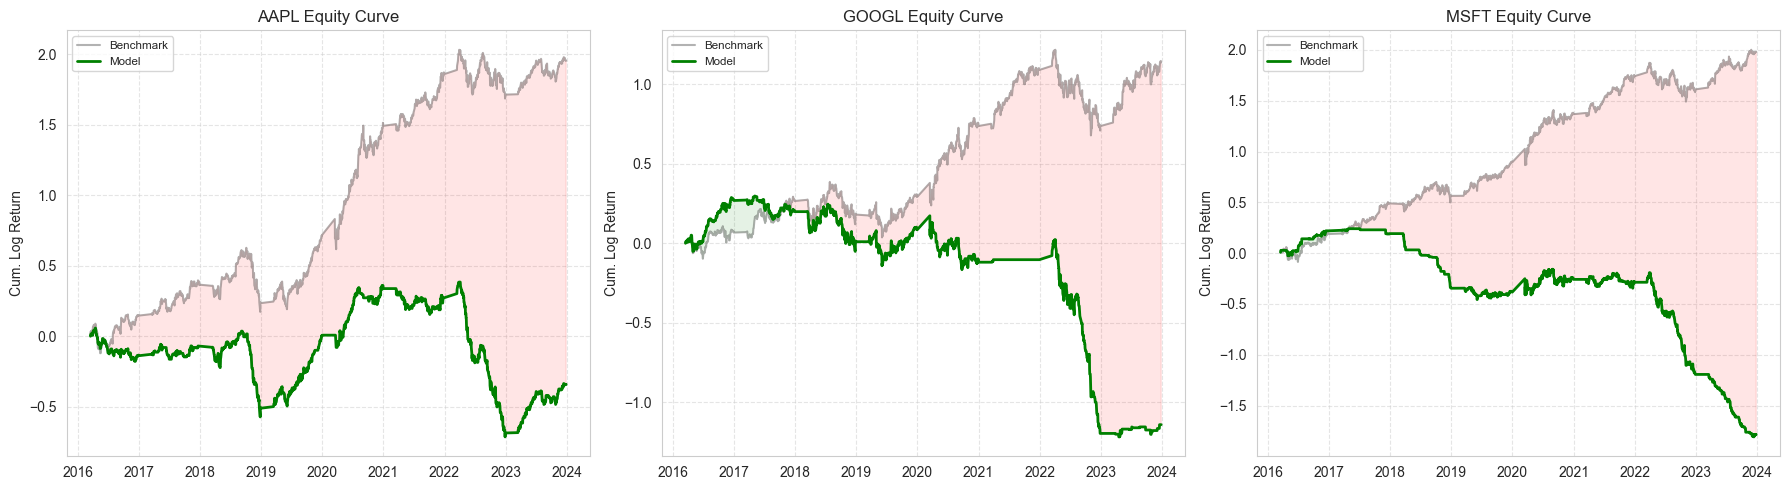


============================== DRAWDOWN ==============================


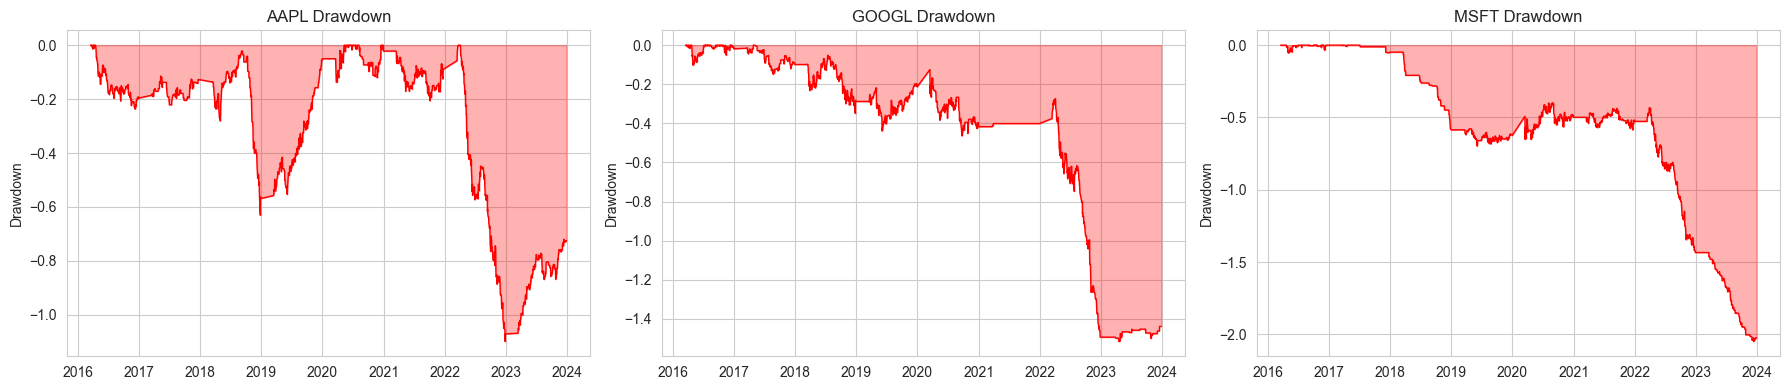


============================== ROLLING ACCURACY ==============================


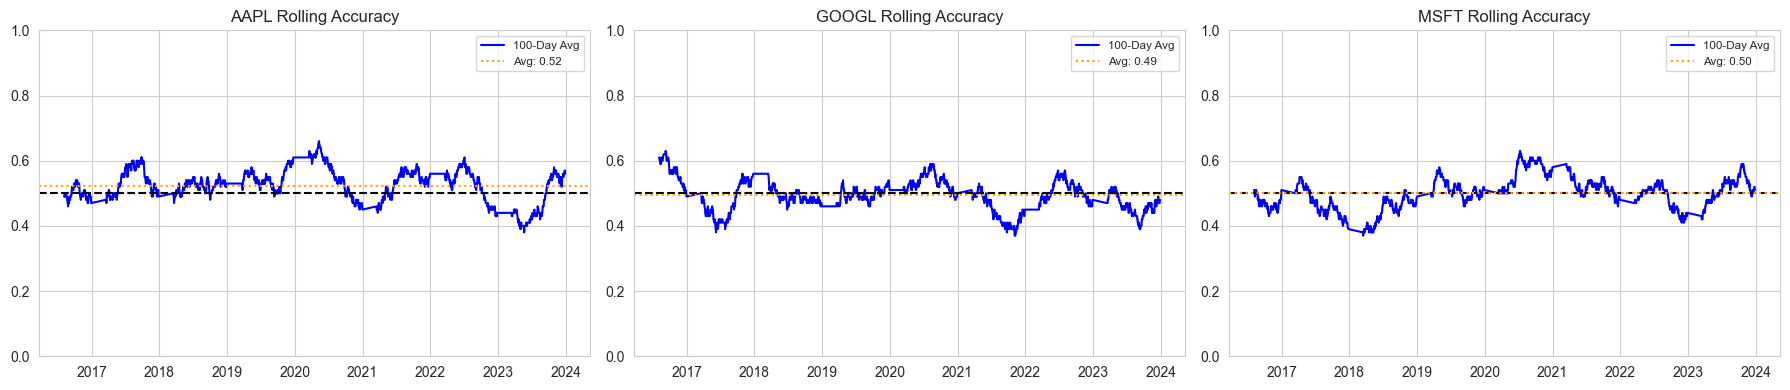


============================== CONFIDENCE DISTRIBUTION ==============================


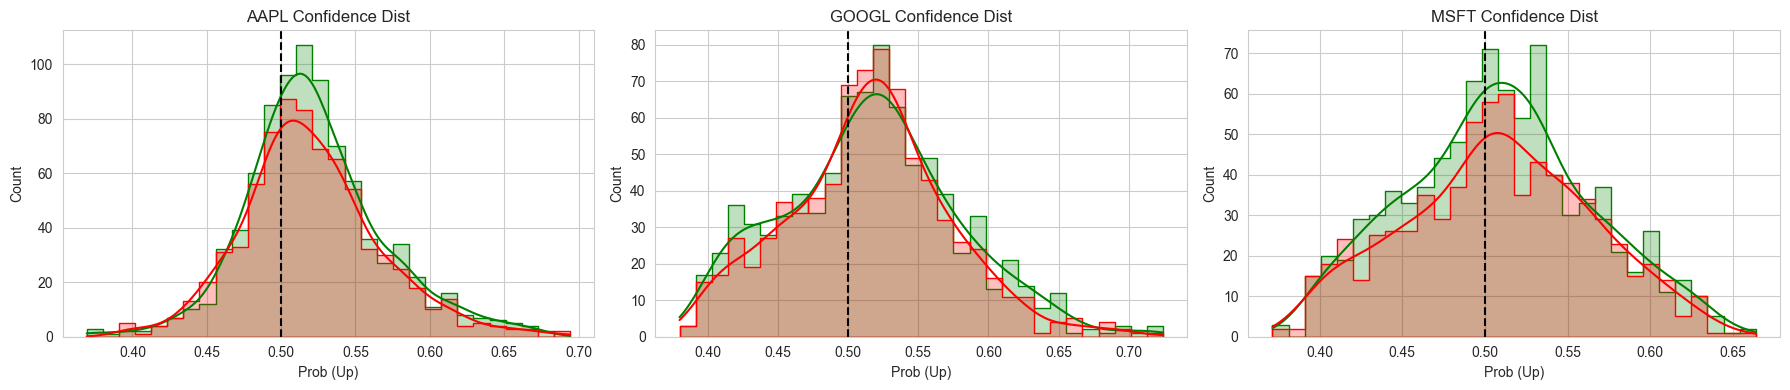


============================== ROC CURVE ==============================


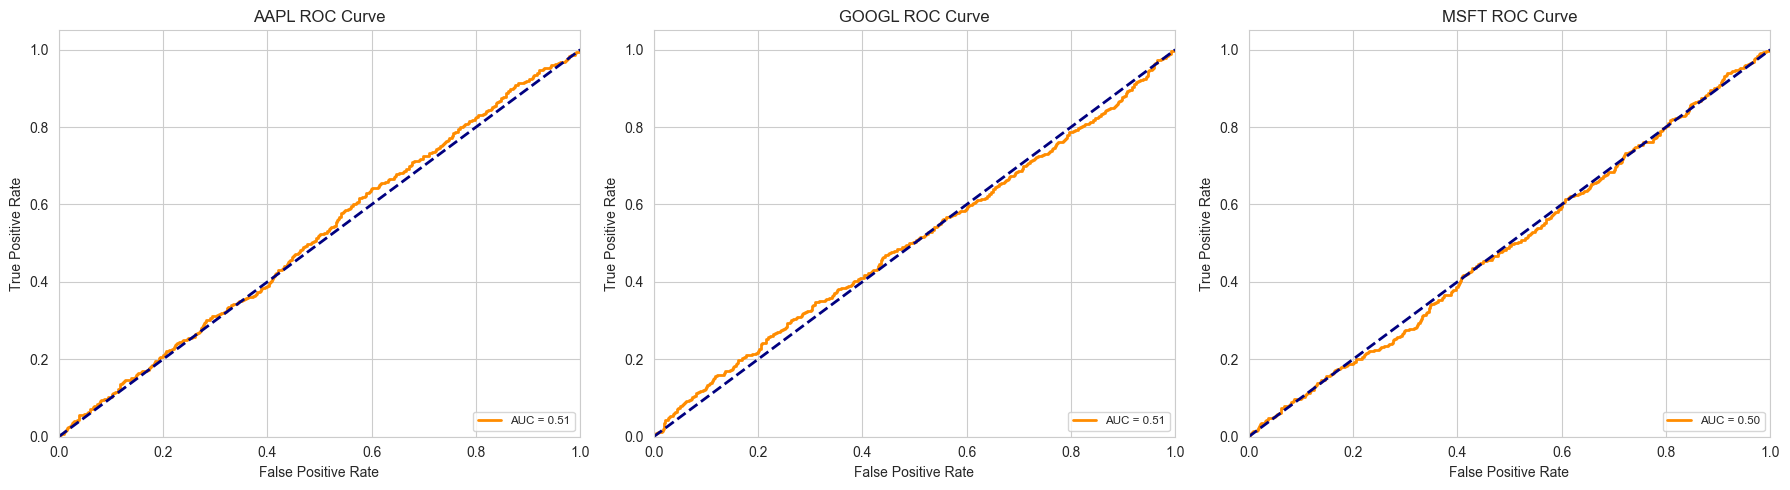


============================== ANNUAL RETURNS ==============================


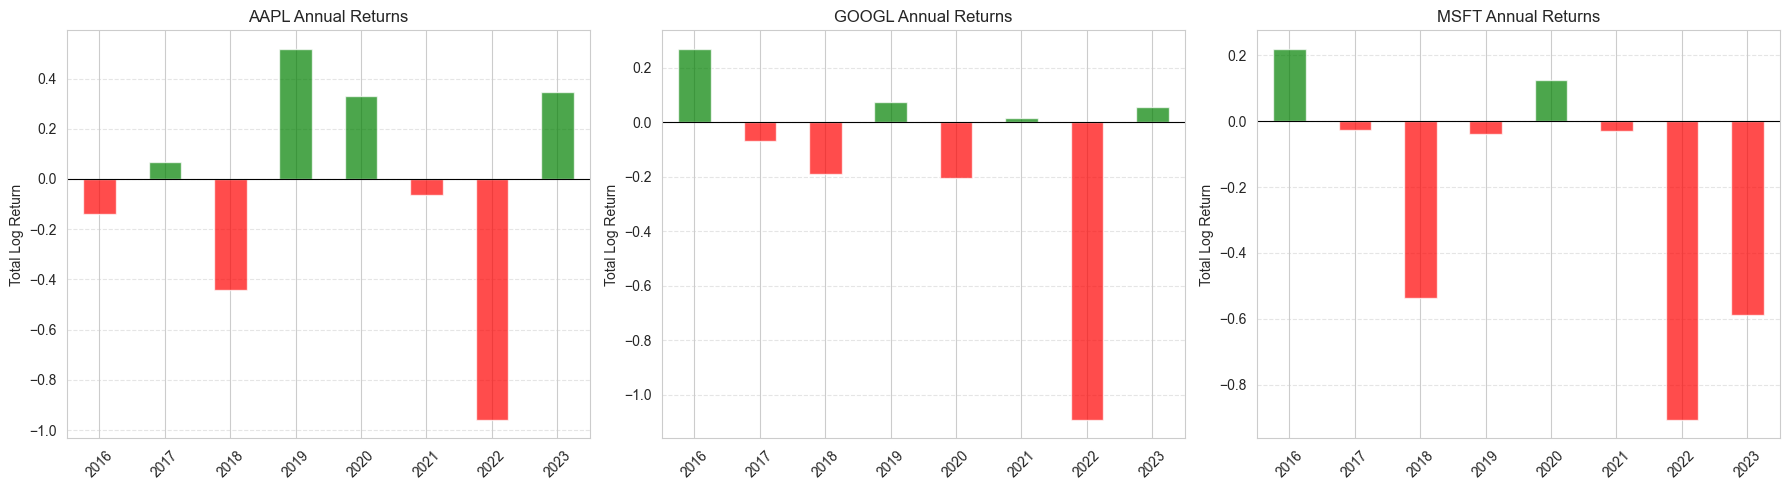


============================== MONTHLY HEATMAP ==============================


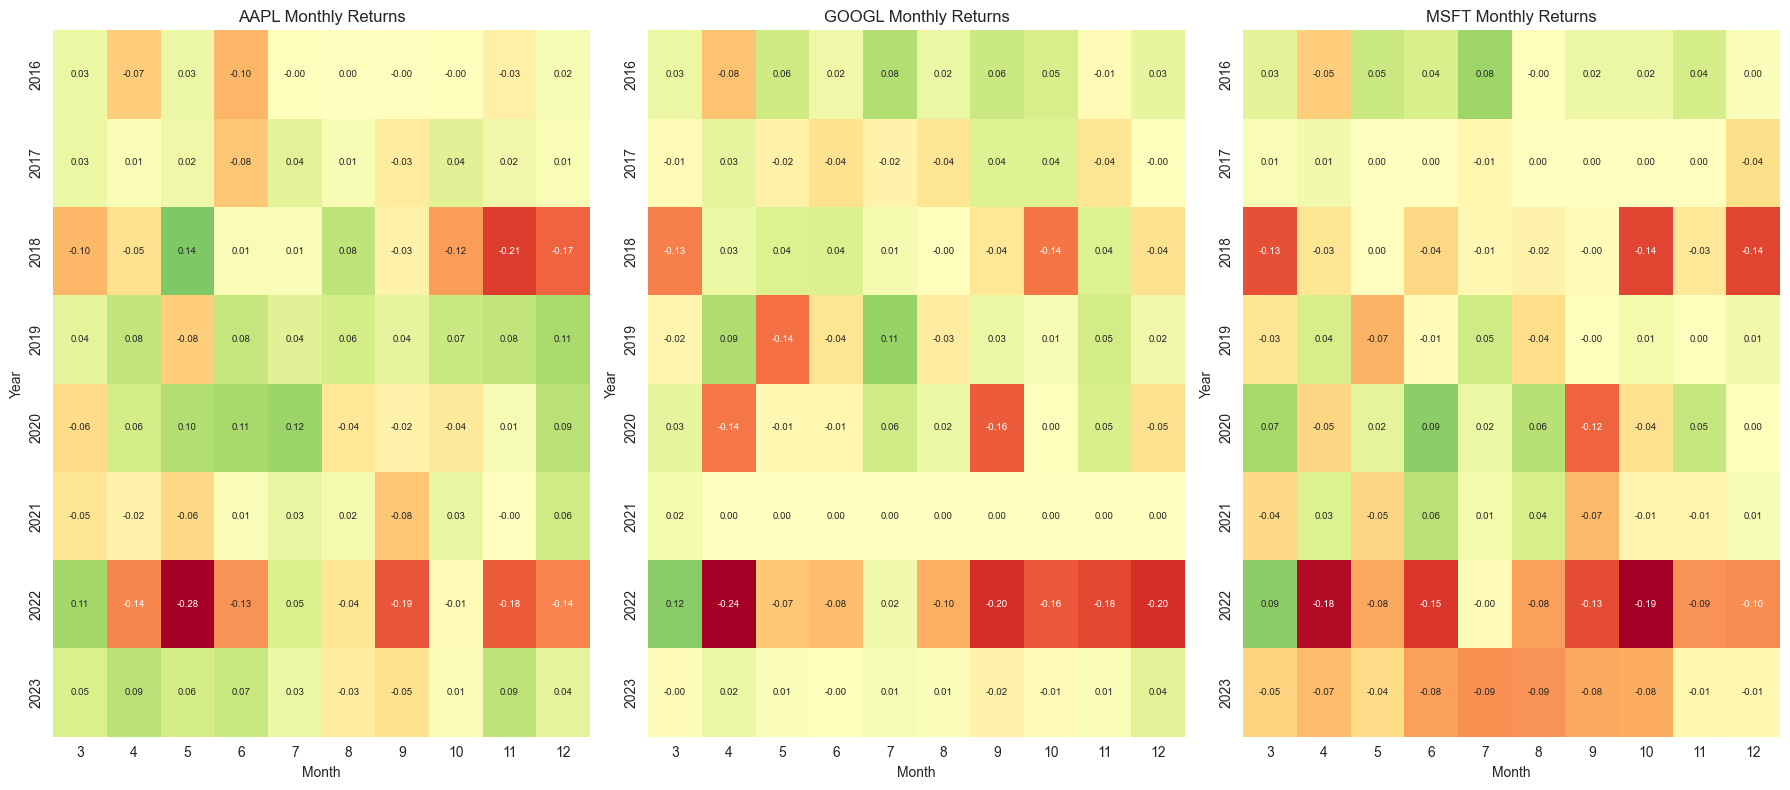


============================== PROFIT/LOSS DISTRIBUTION ==============================


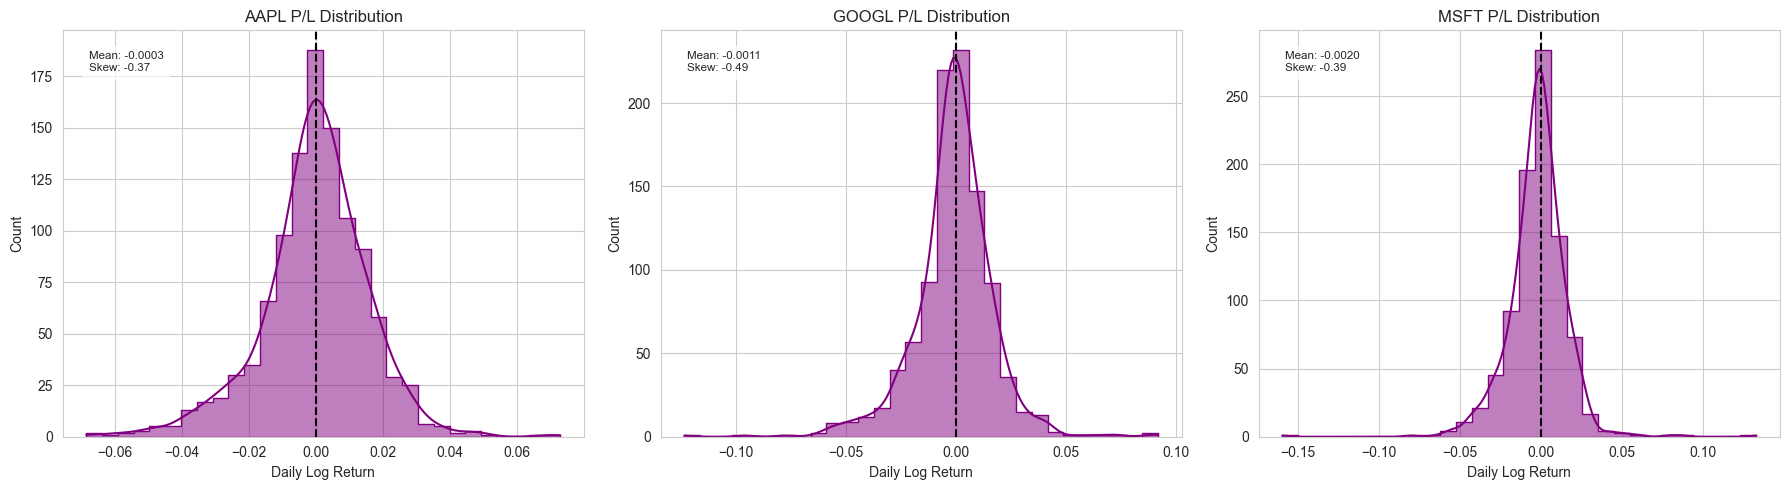

In [336]:
tickers = ['AAPL', 'GOOGL', 'MSFT']
current_model_type = 'binary'
results_dir = '../models_results'

data_store = {}
valid_tickers = []

for ticker in tickers:
    filename = f"detailed_res_{ticker}_{current_model_type}.csv"
    path = os.path.join(results_dir, filename)
    
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
        
    if current_model_type == 'binary':
         df['Signal'] = df['Predicted'] 
    else: 
         df['Signal'] = df['Predicted'].map({2: 1, 0: -1, 1: 0})

    df['Strategy_Return'] = df['Signal'] * df['Log_Return']
    df['Cum_Bench'] = df['Log_Return'].cumsum()
    df['Cum_Strat'] = df['Strategy_Return'].cumsum()
        
    data_store[ticker] = df
    valid_tickers.append(ticker)


if valid_tickers:
    n_tickers = len(valid_tickers)
    
    plot_config = [
        (plot_equity_curve, "EQUITY CURVE", 5),
        (plot_drawdown, "DRAWDOWN", 4),
        (plot_rolling_accuracy, "ROLLING ACCURACY", 4),
        (plot_proba_dist, "CONFIDENCE DISTRIBUTION", 4),
        (plot_roc, "ROC CURVE", 5),
        (plot_annual_returns, "ANNUAL RETURNS", 5),
        (plot_monthly_heatmap, "MONTHLY HEATMAP", 8),
        (plot_returns_distribution, "PROFIT/LOSS DISTRIBUTION", 5)
    ]
    
    for plot_func, section_title, height in plot_config:
        print(f"\n{'='*30} {section_title} {'='*30}")
        
        fig, axes = plt.subplots(1, n_tickers, figsize=(6 * n_tickers, height))
        
        if n_tickers == 1: 
            axes = [axes]
        
        for i, ticker in enumerate(valid_tickers):
            df_copy = data_store[ticker].copy()
            plot_func(df_copy, axes[i], ticker)
            
        plt.tight_layout()
        plt.show()

# Visualization for TBM model

### Comparison with baselines

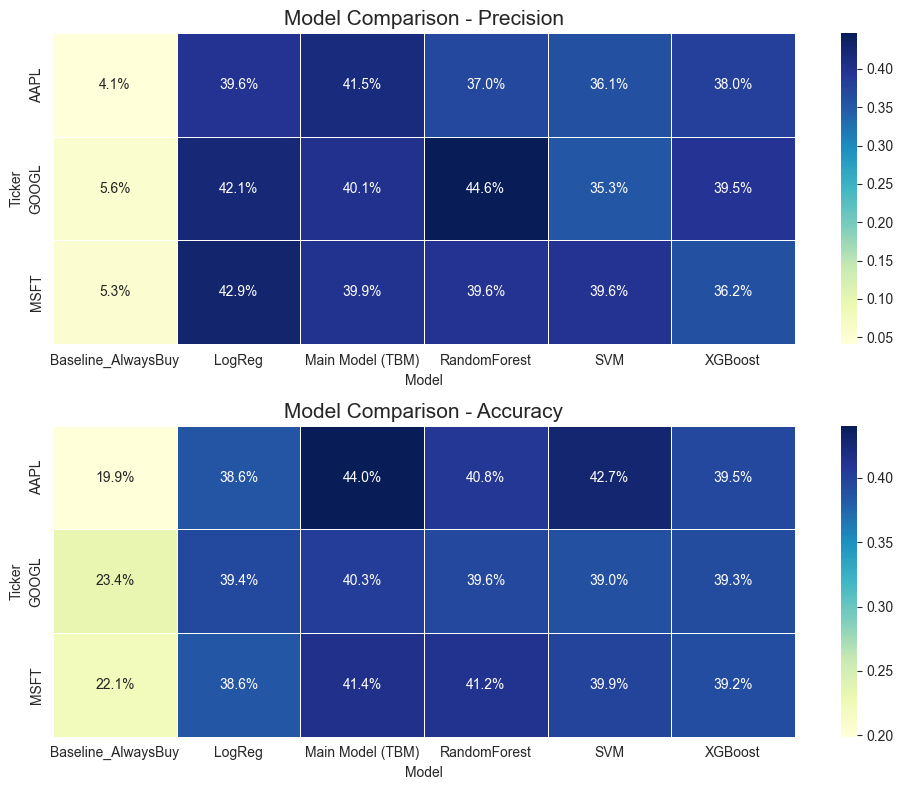

In [337]:
df = pd.read_csv('../main_model/results/final_result_for__matrix.csv')

prec_df = df.pivot(index='Ticker', columns='Model', values='Precision')
acc_df = df.pivot(index='Ticker', columns='Model', values='Accuracy')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

sns.heatmap(prec_df, annot=True, fmt=".1%", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title('Model Comparison - Precision', fontsize=15)
axes[0].set_ylabel('Ticker')
axes[0].set_xlabel('Model')

sns.heatmap(acc_df, annot=True, fmt=".1%", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title('Model Comparison - Accuracy', fontsize=15)
axes[1].set_ylabel('Ticker')
axes[1].set_xlabel('Model')

plt.tight_layout()
plt.show()


============================== EQUITY CURVE ==============================


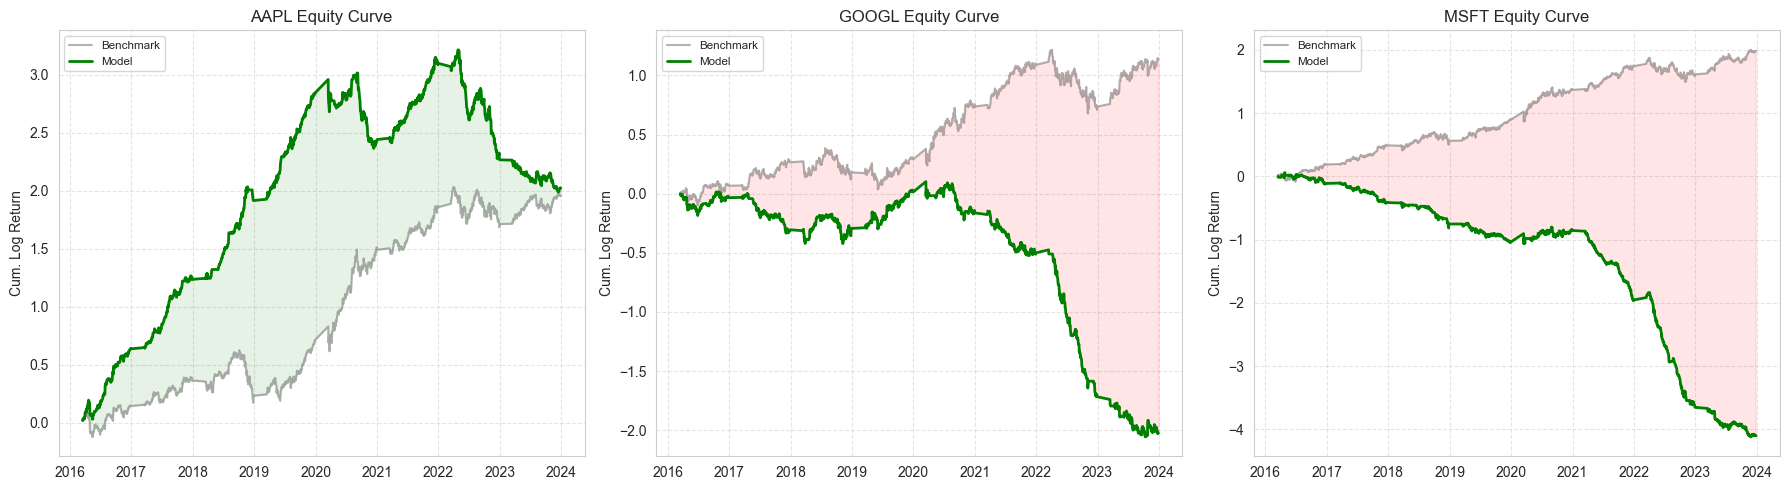


============================== DRAWDOWN ==============================


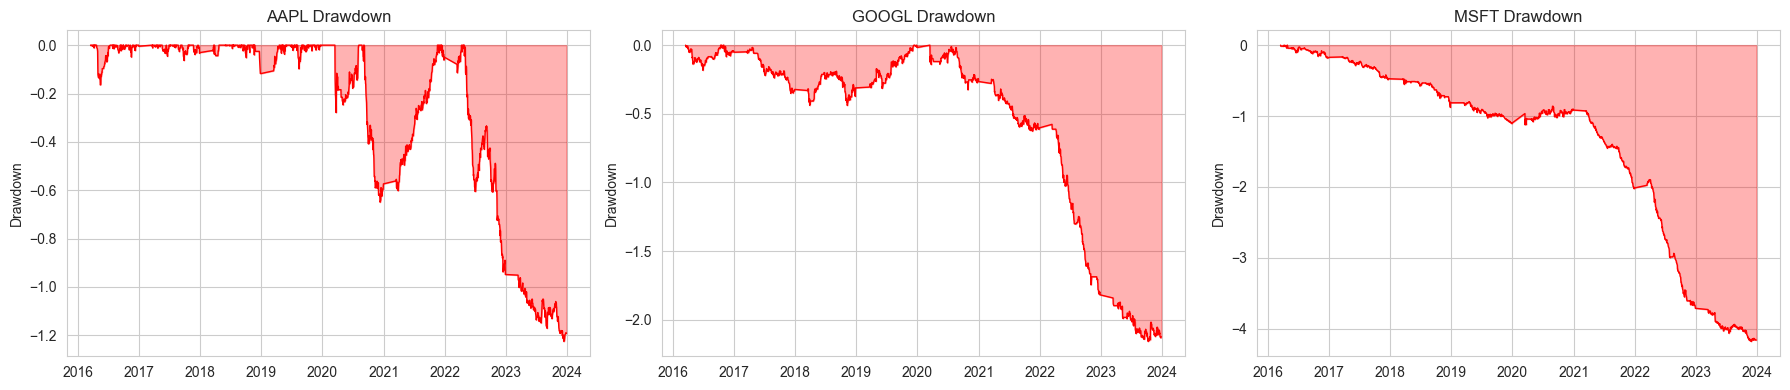


============================== ROLLING ACCURACY ==============================


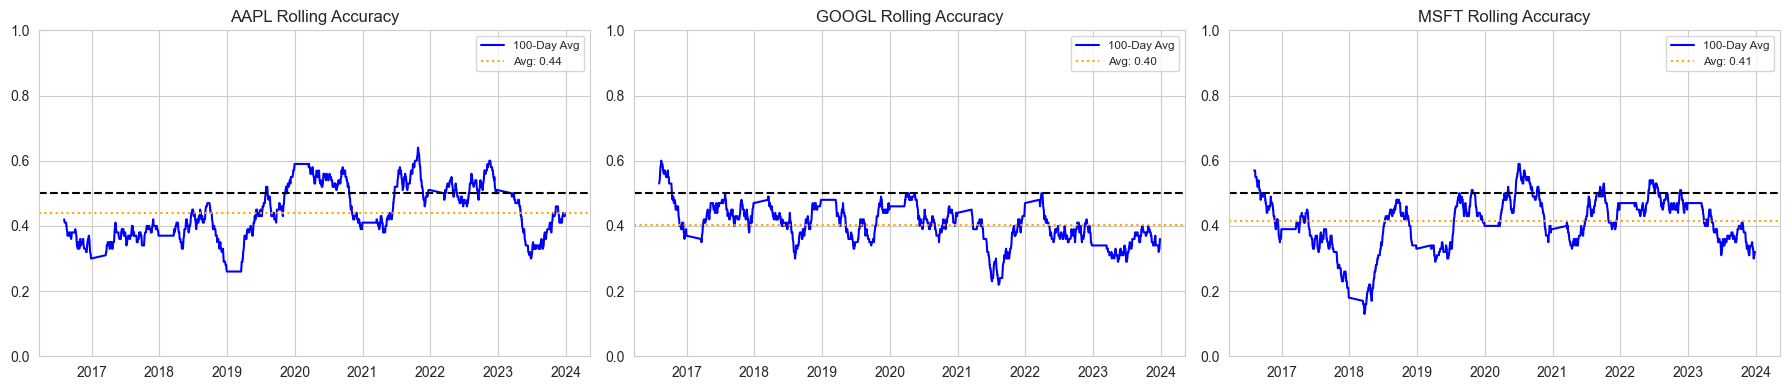


============================== CONFIDENCE DISTRIBUTION (PROFIT) ==============================


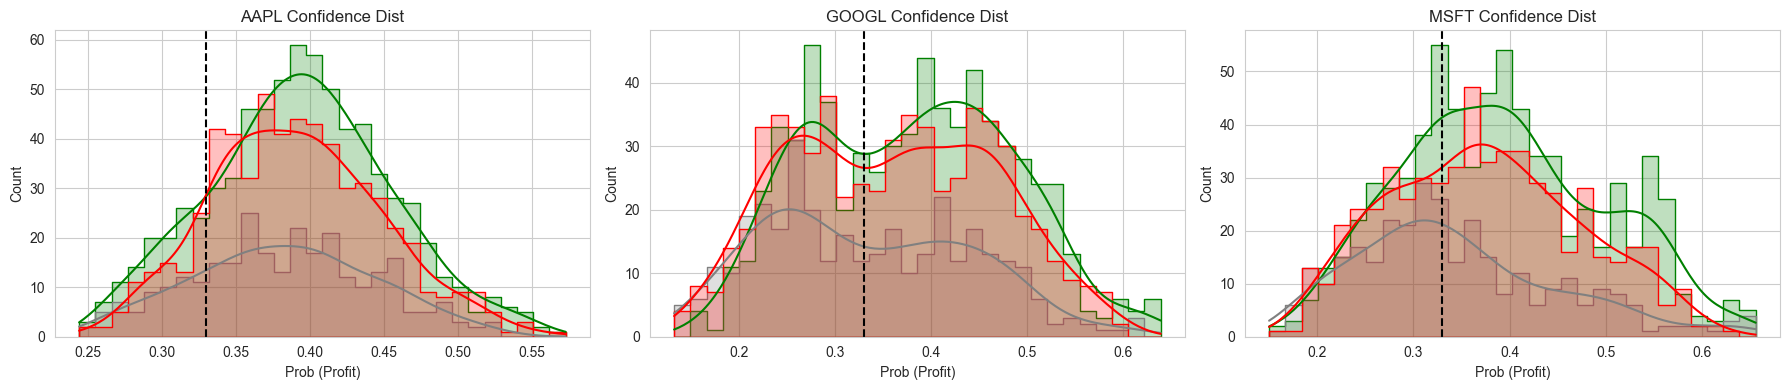


============================== ANNUAL RETURNS ==============================


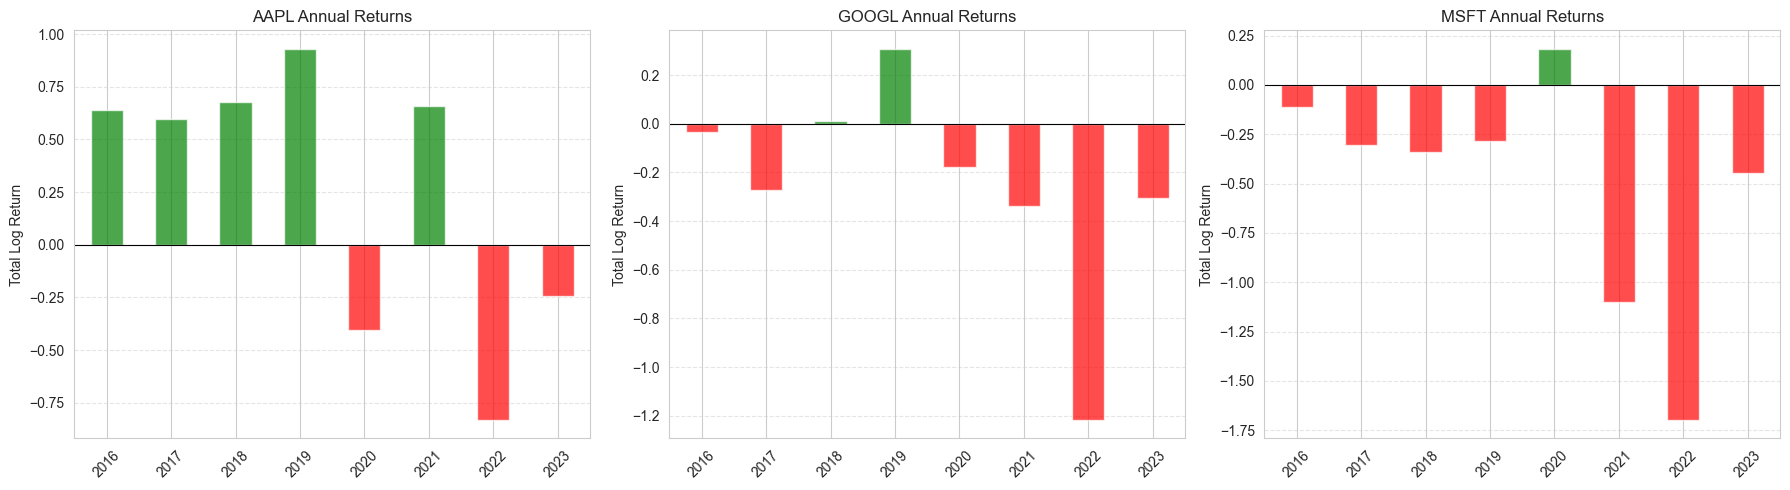


============================== MONTHLY HEATMAP ==============================


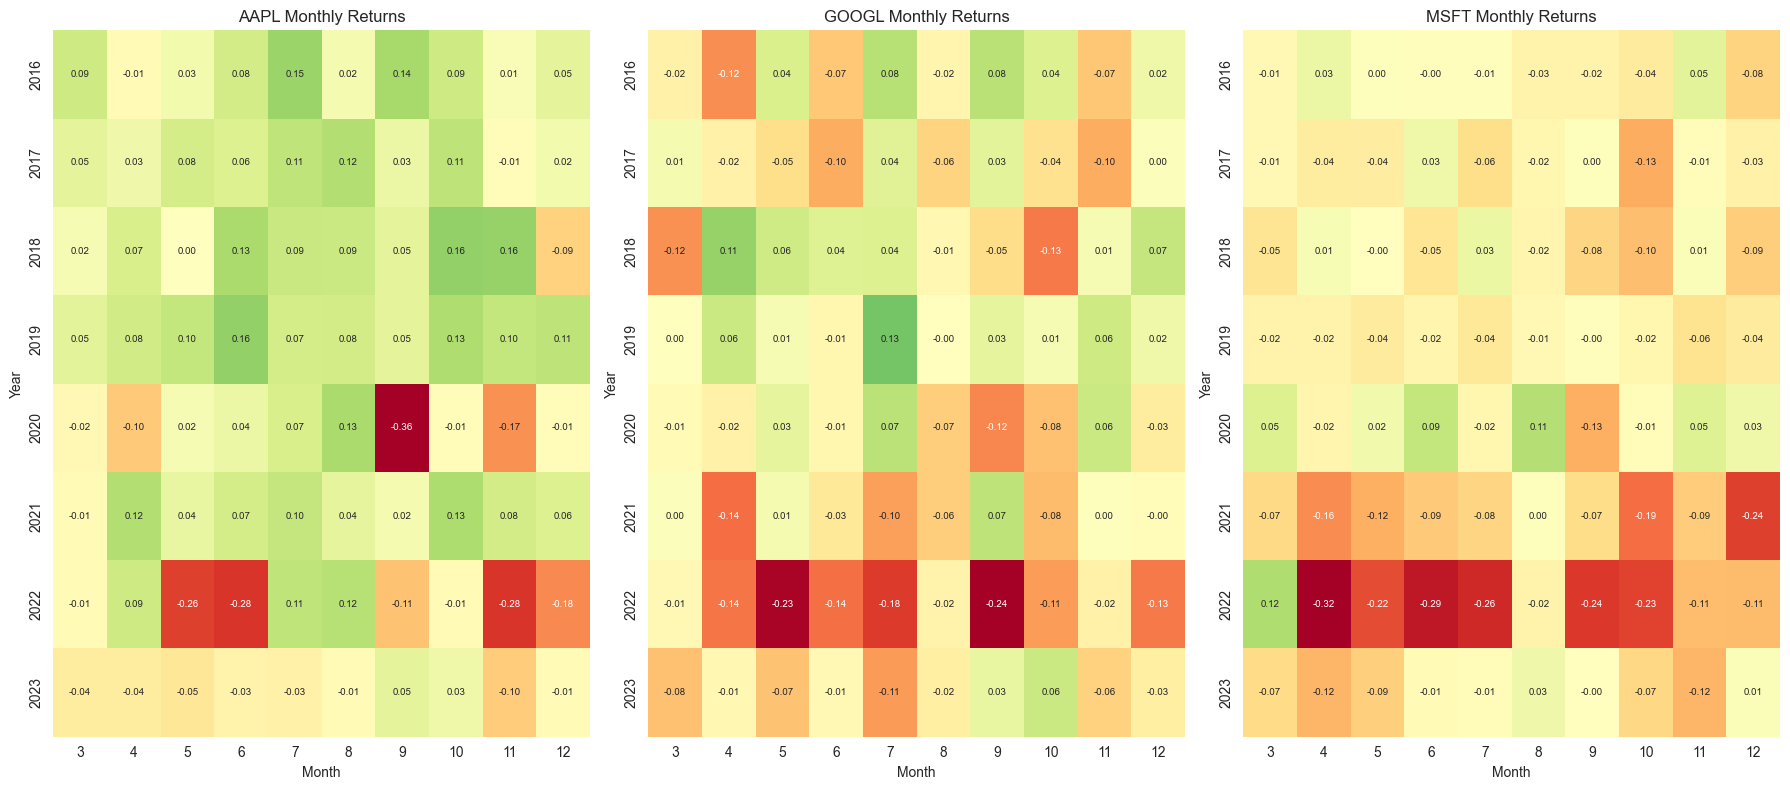


============================== PROFIT/LOSS DISTRIBUTION ==============================


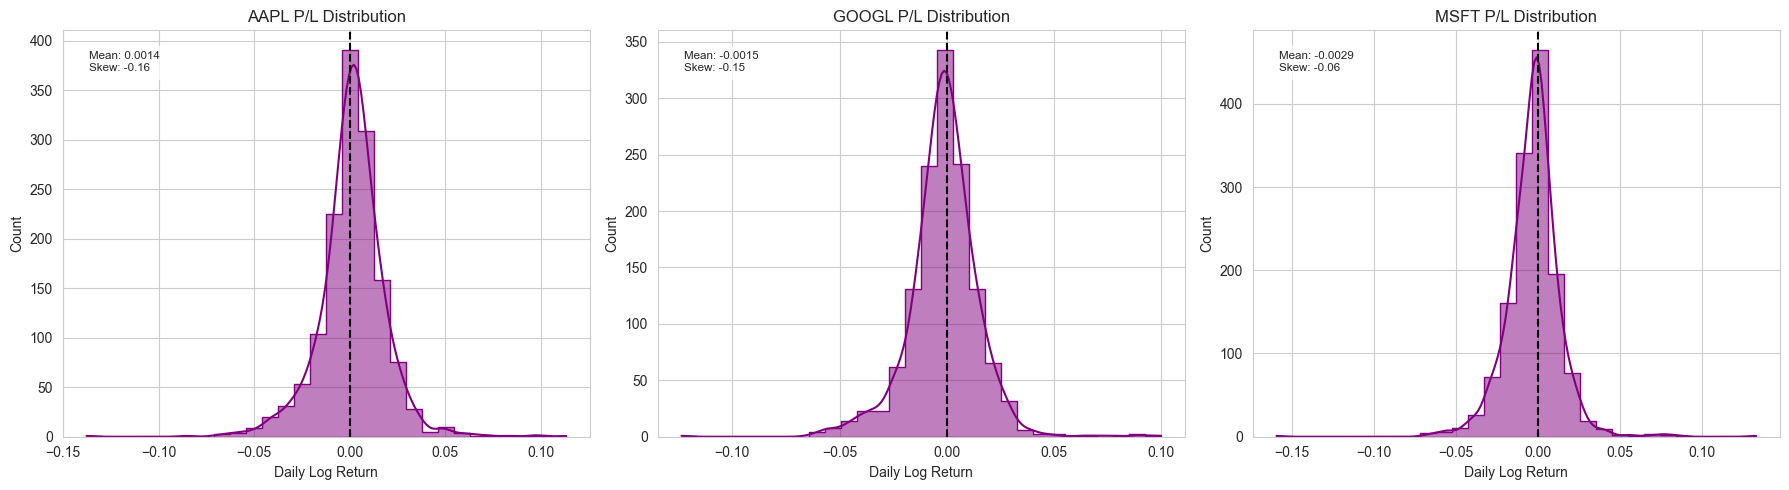

In [338]:
tickers = ['AAPL', 'GOOGL', 'MSFT']
current_model_type = 'tbm'
results_dir = '../models_results'

data_store = {}
valid_tickers = []

for ticker in tickers:
    filename = f"detailed_res_{ticker}_{current_model_type}.csv"
    path = os.path.join(results_dir, filename)
    
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['Signal'] = df['Predicted']

    df['Strategy_Return'] = df['Signal'] * df['Log_Return']
    df['Cum_Bench'] = df['Log_Return'].cumsum()
    df['Cum_Strat'] = df['Strategy_Return'].cumsum()
        
    data_store[ticker] = df
    valid_tickers.append(ticker)


if valid_tickers:
    n_tickers = len(valid_tickers)
    
    plot_config = [
        (plot_equity_curve, "EQUITY CURVE", 5),
        (plot_drawdown, "DRAWDOWN", 4),
        (plot_rolling_accuracy, "ROLLING ACCURACY", 4),
        (plot_proba_dist, "CONFIDENCE DISTRIBUTION (PROFIT)", 4),
        (plot_annual_returns, "ANNUAL RETURNS", 5),
        (plot_monthly_heatmap, "MONTHLY HEATMAP", 8),
        (plot_returns_distribution, "PROFIT/LOSS DISTRIBUTION", 5)
    ]
    
    for plot_func, section_title, height in plot_config:
        print(f"\n{'='*30} {section_title} {'='*30}")
        
        fig, axes = plt.subplots(1, n_tickers, figsize=(6 * n_tickers, height))
        
        if n_tickers == 1: 
            axes = [axes]
        
        for i, ticker in enumerate(valid_tickers):
            df_copy = data_store[ticker].copy()
            plot_func(df_copy, axes[i], ticker)
            
        plt.tight_layout()
        plt.show()